## Author
Name: Zhihao Cui <br>
Institute: School of Mathematics and Statistics <br>
No: 20233002662

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# 1. 加载数据
df = pd.read_csv("car_dataset.csv")
print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded: 301 rows x 9 columns



Missing Values:
Series([], dtype: int64)

Duplicate Rows: 2

Skewness Check:
Owner            7.616850
Kms_Driven       6.436013
Present_Price    4.083150
Selling_Price    2.493422
Year            -1.246189
dtype: float64

Recommendation:

Outlier Check (IQR Method):

Correlation Matrix (Top correlated pairs):
Selling_Price  Present_Price    0.878983
dtype: float64

Recommendation:


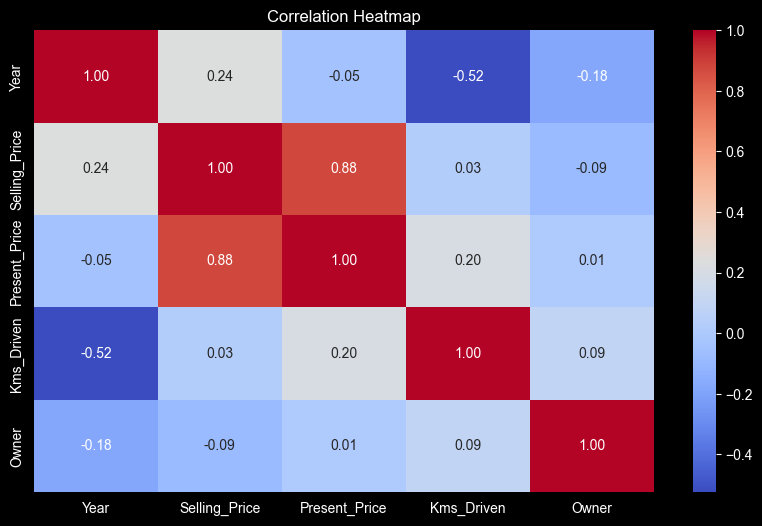

In [3]:
# 2. 数据探索（EDA）
# 缺失值和重复行检查
missing = df.isnull().sum()
print("\nMissing Values:")
print(missing[missing > 0])

duplicate = df.duplicated().sum()
print("\nDuplicate Rows:", duplicate)

# 偏度检查：判断各数值特征的分布是否对称（绝对值>1为高度偏斜）
skewed_features = df.select_dtypes(include=['number']).apply(lambda x: x.skew()).sort_values(ascending=False)
print("\nSkewness Check:")
print(skewed_features)

print("\nRecommendation:")
for col, skew in skewed_features.items():
    if abs(skew) > 1:
        print(f"Warning: {col} is highly skewed (skew={skew:.2f}). Suggest: Apply log or sqrt transform.")
    elif abs(skew) > 0.5:
        print(f"Info: {col} is moderately skewed (skew={skew:.2f}). Transform optional.")
    else:
        print(f"OK: {col} is fairly symmetric (skew={skew:.2f}). No action needed.")

# 异常值检测（IQR准则）
print("\nOutlier Check (IQR Method):")
for col in df.select_dtypes(include=['number']):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    if outlier_count > 0:
        print(f"Warning: {col}: {outlier_count} outliers detected.")
    else:
        print(f"OK: {col}: No significant outliers.")

# 相关性分析：找出高度相关的特征对（>0.7）
correlation = df.corr(numeric_only=True)
cor_matrix = correlation.abs().unstack().sort_values(ascending=False).drop_duplicates()
top_corr = cor_matrix[(cor_matrix < 1) & (cor_matrix > 0.7)]
print("\nCorrelation Matrix (Top correlated pairs):")
print(top_corr)

print("\nRecommendation:")
for (f1, f2), corr_val in top_corr.items():
    print(f"Warning: {f1} & {f2} have high correlation ({corr_val:.2f}). Suggest: Keep only one or apply dimensionality reduction (e.g., PCA).")

# 热力图可视化
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [4]:
# 3. 数据清洗
df = df.drop_duplicates()               # 删除重复行
df = df.drop(columns=['Car_Name'])      # 去除不需要的特征

# 使用IQR方法删除各数值特征的异常值
def remove_outliers(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]
    return filtered_df

df = remove_outliers(df, 'Year')
df = remove_outliers(df, 'Selling_Price')
df = remove_outliers(df, 'Present_Price')
df = remove_outliers(df, 'Kms_Driven')
df = remove_outliers(df, 'Owner')

print(f"\nData after removing outliers and duplicates: {df.shape[0]} rows x {df.shape[1]} columns")


Data after removing outliers and duplicates: 260 rows x 8 columns


In [5]:
# 4. 特征工程
# 车龄 = 当前年份(2025) - 出厂年份
df['Car_Age'] = 2025 - df['Year']
df = df.drop(columns=['Year'])

# 对偏斜特征进行对数变换（log1p 可处理零值，还原时使用 expm1）
df['Kms_Driven'] = np.log1p(df['Kms_Driven'])
df['Present_Price'] = np.log1p(df['Present_Price'])
df['Selling_Price'] = np.log1p(df['Selling_Price'])
df['Owner'] = np.log1p(df['Owner'])
df['Car_Age'] = np.log1p(df['Car_Age'])

# 分类特征独热编码（drop_first 避免多重共线性）
df = pd.get_dummies(df, drop_first=True)

In [6]:
# 5. 分割训练集和测试集
X = df.drop(columns=['Selling_Price'])
y = df['Selling_Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# 6. 训练随机森林模型（在 log 尺度上）
model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\nModel Evaluation (Log Scale):")
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


Model Evaluation (Log Scale):
R2 Score: 0.97785880556337
RMSE: 0.10191594623405525
MAE: 0.07523153045299329
MSE: 0.010386860096782842


In [8]:
# 7. 逆变换回原始尺度进行评估
y_test_orig = np.expm1(y_test)   # 还原 Selling_Price 原始值
y_pred_orig = np.expm1(y_pred)

mae = mean_absolute_error(y_test_orig, y_pred_orig)
mse = mean_squared_error(y_test_orig, y_pred_orig)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_orig, y_pred_orig)

print("\nEvaluation on Original Scale:")
print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)


Evaluation on Original Scale:
R2 Score: 0.9383687485271885
MAE: 0.4096385712315013
MSE: 0.5433107782829059
RMSE: 0.7370961798048514


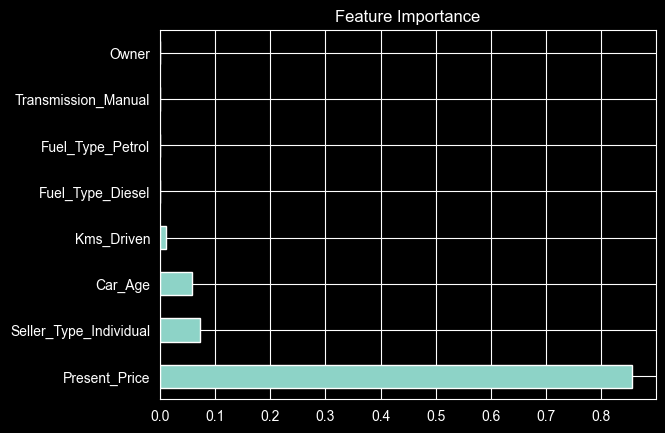

In [9]:
# 8. 特征重要性可视化
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')
plt.title("Feature Importance")
plt.show()

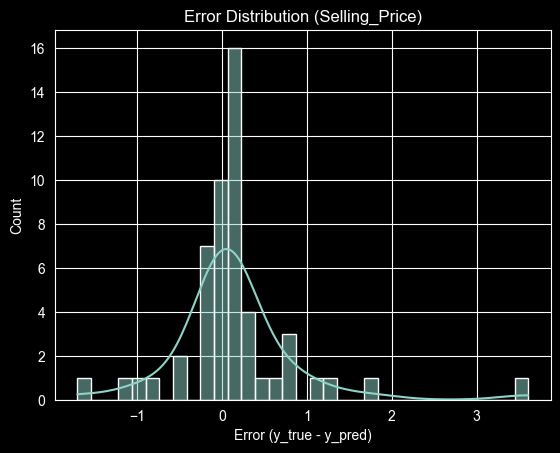

In [10]:
# 9. 预测误差分布
errors = y_test_orig - y_pred_orig
sns.histplot(errors, kde=True)
plt.title("Error Distribution (Selling_Price)")
plt.xlabel("Error (y_true - y_pred)")
plt.show()

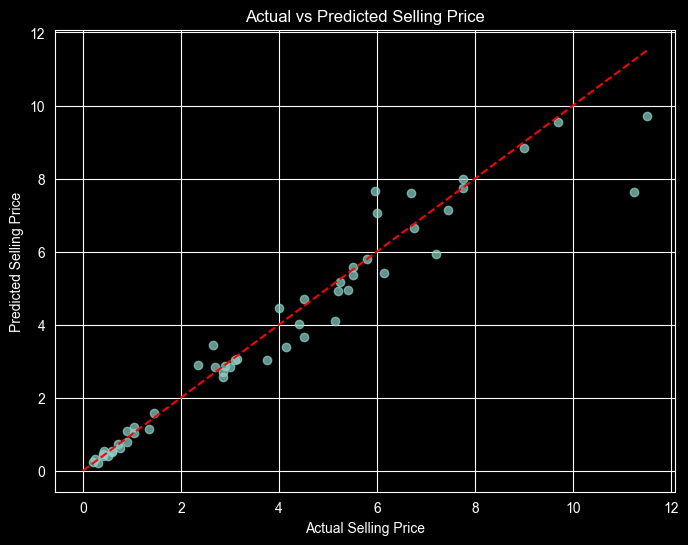


Top 5 Largest Errors:
     Actual  Predicted     Error
91    11.25   7.642250  3.607750
299   11.50   9.725964  1.774036
247    5.95   7.653772 -1.703772
253    7.20   5.937551  1.262449
278    6.00   7.066314 -1.066314


In [11]:
# 10. 实际值 vs 预测值散点图（带理想对角线）
plt.figure(figsize=(8, 6))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.7)
plt.plot([0, max(y_test_orig)], [0, max(y_test_orig)], color='red', linestyle='--')
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.show()

# 输出误差最大的5个样本
df_result = pd.DataFrame({
    'Actual': y_test_orig,
    'Predicted': y_pred_orig,
    'Error': y_test_orig - y_pred_orig
})
print("\nTop 5 Largest Errors:")
print(df_result.sort_values(by='Error', key=abs, ascending=False).head(5))